# Using Assocaitive rule for Market Basket Analysis

### Analysis Plan

## Exploratory Analysis
1. How many total transaction and how many transaction for each month?
2. how many unique total Item sold and for each month?
3. What are the most frequently sold items?
4. What are the most important items that should always be in the store?

## Generating Association rules
5. Create an item matrix
6. Dived a transaction data in to 4 period (number of transaction and Item for each Period)
7. Get a support, confidence and lift value for all item with Apriori Algorithms.
8. Generating Association Rules with apriori algorithm.

## Applying Overall variability for Association rules
9. Make a comparison between the support and confidence and support and all combination.
10. Apply overall variability of association rule for 4 different period to find important rules


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import pyplot
from tabulate import tabulate
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Reading Files

#### January Data

In [2]:
xls = pd.ExcelFile('Original Dataset/January.xlsx')
january_df = pd.read_excel(xls, 'Sales receipt details')

**Exploring Data**

In [3]:
january_df.head()

,Receipt No.,Date,Type,Cashier,Members,Promoter,Item description,Barcode,S/No.,Quantity,Selling price,Revenue,Discount amount,Profit,现金支付,BNU,储值卡支付,T.PAY,Remarks
0,202201280807449510001,2022-01-28 8:07:47 AM,Sales,Tina,Sweet Cake(0000000470),-,-,-,-,1.040,2.60,2.60,0.00,1.3000,2.6,0.0,0.0,0.0,NaN
1,202201280807449510001,2022-01-28 8:07:47 AM,Sales,Tina,Sweet Cake(0000000470),NaN,Spring Onion 大葱,2200006,NaN,0.46,1.15,1.15,0.00,0.5750,NaN,NaN,NaN,NaN,NaN
2,202201280807449510001,2022-01-28 8:07:47 AM,Sales,Tina,Sweet Cake(0000000470),NaN,Spring Onion 大葱,2200006,NaN,0.126,0.32,0.32,0.00,0.1575,NaN,NaN,NaN,NaN,NaN
3,202201280807449510001,2022-01-28 8:07:47 AM,Sales,Tina,Sweet Cake(0000000470),NaN,Spring Onion 大葱,2200006,NaN,0.162,0.40,0.41,0.00,0.2025,NaN,NaN,NaN,NaN,NaN
4,202201280807449510001,2022-01-28 8:07:47 AM,Sales,Tina,Sweet Cake(0000000470),NaN,Spring Onion 大葱,2200006,NaN,0.162,0.40,0.41,0.00,0.2025,NaN,NaN,NaN,NaN,NaN


In [4]:
january_df.shape

(5567, 19)

Selecting only the relevant columns for analysis

In [5]:
jan = january_df[['Receipt No.','Date','Type','Item description','Quantity','Revenue']]

#### February Data

In [6]:
xls = pd.ExcelFile('Original Dataset/February.xlsx')
february_df = pd.read_excel(xls, 'Sales receipt details')

**Exploring Data**

In [7]:
february_df.head()

,Receipt No.,Date,Time,Type,Cashier,Member name,Member ID,Promoter,Item description,Barcode,S/No.,Quantity,Item unit price,Selling price,Revenue,Allowance amount,Remarks
0,202202010801499470001,2022/02/01,08:01:51,Sales,Tina,-,NaN,NaN,R.LA 香烟,8991906241425,NaN,1.0,1.75,1.75,1.75,0.0,NaN
1,202202010819569800002,2022/02/01,08:20:01,Sales,Tina,Domingas R. Ximenes,5614.0,NaN,Roma Sandwich Chocolate 216g,8996001305041,NaN,1.0,0.50,0.50,0.50,0.0,NaN
2,202202010819569800002,2022/02/01,08:20:01,Sales,Tina,Domingas R. Ximenes,5614.0,NaN,Y28 Nutrition Express500ml营养牵线草莓,6902083897765,NaN,1.0,1.00,1.00,1.00,0.0,NaN
3,202202010819569800002,2022/02/01,08:20:01,Sales,Tina,Domingas R. Ximenes,5614.0,NaN,Lagie Kijang Choco Biscuit 21g(1x168x21g),8992957220186,NaN,1.0,0.20,0.20,0.20,0.0,NaN
4,202202010819569800002,2022/02/01,08:20:01,Sales,Tina,Domingas R. Ximenes,5614.0,NaN,Lagie Gajah 30g Kacang Tanah,8992957220070,NaN,1.0,0.20,0.20,0.20,0.0,NaN


In [8]:
february_df.shape

(16581, 17)

Selecting only the relevant columns for analysis

In [9]:
feb = february_df[['Receipt No.','Date','Time','Type','Item description','Quantity','Revenue']]

#### March Data

In [10]:
xls = pd.ExcelFile('Original Dataset/March.xlsx')
march_df = pd.read_excel(xls, 'Sales receipt details')

**Exploring Data**

In [11]:
march_df.head()

,Receipt No.,Date,Time,Type,Cashier,Member name,Member ID,Promoter,Item description,Barcode,S/No.,Quantity,Item unit price,Selling price,Revenue,Allowance amount,Remarks
0,202203010803305150001,2022/03/01,08:03:33,Sales,Tina,-,NaN,NaN,Buavita 250ml Guava(1x24x250ml),8998009020186,NaN,1.0,0.65,0.65,0.65,0.0,NaN
1,202203010803305150001,2022/03/01,08:03:33,Sales,Tina,-,NaN,NaN,Buavita 250ml Orange(1x24x250ml),8998009020179,NaN,1.0,0.65,0.65,0.65,0.0,NaN
2,202203010808350140002,2022/03/01,08:08:37,Sales,Tina,Afran Donio Lay,2152.0,NaN,SedaapCup 85g Goreng,8998866200813,NaN,1.0,0.45,0.45,0.45,0.0,NaN
3,202203010808350140002,2022/03/01,08:08:37,Sales,Tina,Afran Donio Lay,2152.0,NaN,Buavita 250ml Orange(1x24x250ml),8998009020179,NaN,1.0,0.65,0.65,0.65,0.0,NaN
4,202203010808350140002,2022/03/01,08:08:37,Sales,Tina,Afran Donio Lay,2152.0,NaN,Tom Milk Ananas Plineapple 125g(1x24x125g),5602835002102,00990,1.0,0.60,0.60,0.60,0.0,NaN


In [12]:
march_df.shape

(18409, 17)

Selecting only relevant columns for analysis

In [13]:
mar = march_df[['Receipt No.','Date','Time','Type','Item description','Quantity','Revenue']]

#### April Data

In [14]:
xls = pd.ExcelFile('Original Dataset/april.xlsx')
april_df = pd.read_excel(xls, 'Sales receipt details')

**Exploring Data**

In [15]:
april_df.head()

,Receipt No.,Date,Time,Type,Cashier,Member name,Member ID,Promoter,Item description,Barcode,S/No.,Quantity,Item unit price,Selling price,Revenue,Allowance amount,Remarks
0,202204010959251070001,2022/04/01,09:59:27,Sales,Tina,-,NaN,NaN,Indomilk Kids 115ml Coklat,8993007000239,NaN,1.000,0.25,0.25,0.25,0.0,NaN
1,202204011003518550002,2022/04/01,10:03:55,Sales,Tina,Joao Miltou Brito,1175.0,NaN,Le Minerale 600ml,8996001600269,NaN,1.000,0.25,0.25,0.25,0.0,NaN
2,202204011003518550002,2022/04/01,10:03:55,Sales,Tina,Joao Miltou Brito,1175.0,NaN,Indomilk Kotak Vanila 190ml,8993007000024,NaN,1.000,0.40,0.40,0.40,0.0,NaN
3,202204011003518550002,2022/04/01,10:03:55,Sales,Tina,Joao Miltou Brito,1175.0,NaN,Frozen Cooked Head On Vannamei Shrimp 500g 红熟虾,8005201782313,NaN,1.000,6.95,6.95,6.95,0.0,NaN
4,202204011003518550002,2022/04/01,10:03:55,Sales,Tina,Joao Miltou Brito,1175.0,NaN,Milk Fish 牛奶鱼(1x10kg),2200430,NaN,0.442,3.75,1.66,1.66,0.0,NaN


In [16]:
april_df.shape

(17865, 17)

selecting only the relevant columns for analysis

In [17]:
apr = april_df[['Receipt No.','Date','Time','Type','Item description','Quantity','Revenue']]

### Merging All Months Data

To Merge all data we first need to match all of the columns.but here we see that the january data have data column which represent the date and time both. but in all of other 3 month dataframe there are two seperate columns for date and time. so we first need to merge the date and time in all of the other 3 dataframe before merging the datasets

In [18]:
feb['Date'] = feb['Date']+' '+feb['Time']
del feb['Time']

In [19]:
mar['Date'] = mar['Date']+' '+mar['Time']
del mar['Time']

In [20]:
apr['Date'] = apr['Date']+' '+apr['Time']
del apr['Time']

**Merging Datasets**

In [21]:
df = pd.concat([jan,feb,mar,apr])

# Exploratory Data Analysis - EDA

In [22]:
df.head()

,Receipt No.,Date,Type,Item description,Quantity,Revenue
0,202201280807449510001,2022-01-28 8:07:47 AM,Sales,-,1.040,2.60
1,202201280807449510001,2022-01-28 8:07:47 AM,Sales,Spring Onion 大葱,0.46,1.15
2,202201280807449510001,2022-01-28 8:07:47 AM,Sales,Spring Onion 大葱,0.126,0.32
3,202201280807449510001,2022-01-28 8:07:47 AM,Sales,Spring Onion 大葱,0.162,0.41
4,202201280807449510001,2022-01-28 8:07:47 AM,Sales,Spring Onion 大葱,0.162,0.41


In [23]:
df.shape

(58422, 6)

#### Improving columns Name

In [24]:
df.columns

Index(['Receipt No.', 'Date', 'Type', 'Item description', 'Quantity',
       'Revenue'],
      dtype='object')

In [25]:
df.rename(columns = {'Receipt No.':'Receipt_No','Item description':'Item_description'},inplace=True)

In [26]:
df.columns

Index(['Receipt_No', 'Date', 'Type', 'Item_description', 'Quantity',
       'Revenue'],
      dtype='object')

#### Handling Missing Values

In [27]:
df.isnull().sum()

Receipt_No          1142
Date                1142
Type                1142
Item_description       4
Quantity            1129
Revenue             1126
dtype: int64

deleting all of the missing values

In [28]:
df.dropna(inplace = True)

In [29]:
df.isnull().sum()

Receipt_No          0
Date                0
Type                0
Item_description    0
Quantity            0
Revenue             0
dtype: int64

**Meta Data**

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 57280 entries, 0 to 17863
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Receipt_No        57280 non-null  object 
 1   Date              57280 non-null  object 
 2   Type              57280 non-null  object 
 3   Item_description  57280 non-null  object 
 4   Quantity          57280 non-null  object 
 5   Revenue           57280 non-null  float64
dtypes: float64(1), object(5)
memory usage: 3.1+ MB


**Correcting Datatypes**

In [31]:
df['Date'] = pd.to_datetime(df['Date'])
df['Quantity']=df['Quantity'].astype('float64')

In [32]:
df.dtypes

Receipt_No                  object
Date                datetime64[ns]
Type                        object
Item_description            object
Quantity                   float64
Revenue                    float64
dtype: object

#### Checking total Unique value

In [33]:
df.nunique()

Receipt_No          18850
Date                18850
Type                    2
Item_description     7746
Quantity             1287
Revenue              1408
dtype: int64

Here we can see that there are 18850 unique receipts that mean 18850 unique transactions

#### Checking the values of each variable

In [34]:
df.apply(lambda x: print(x.value_counts(),"\n"))

202201301108421130067    62
202204031815279550154    53
202204011650523050122    49
202204031645114460127    47
202203131141208310100    46
                         ..
202203261301166480097     1
202202160949349550050     1
202203261102448910095     1
202202210905109500034     1
202202071235388180126     1
Name: Receipt_No, Length: 18850, dtype: int64 

2022-01-30 11:09:36    62
2022-04-03 18:15:31    53
2022-04-01 16:50:59    49
2022-04-03 16:45:18    47
2022-03-13 11:41:34    46
                       ..
2022-03-26 13:01:18     1
2022-02-16 09:49:35     1
2022-03-26 11:02:44     1
2022-02-21 09:05:13     1
2022-02-07 12:35:39     1
Name: Date, Length: 18850, dtype: int64 

Sales     57236
Return       44
Name: Type, dtype: int64 

Aqua 1500ml(1x12x1500ml)                       2123
Non-Woven Bag无纺布袋 Pcs（S）                       1635
Non-Woven Bag无纺布袋 Pcs（M）                       1465
Aqua 600ml(1x24x600ml)                         1460
Chicken Leg Quarter/ Paha Besar 鸡大腿            12

Receipt_No          None
Date                None
Type                None
Item_description    None
Quantity            None
Revenue             None
dtype: object

Here we can see that the values of items description contains some chinese characters also do contain '-' as a value we need to correct it

**Correcting the values of Item Description columns**

In [35]:
df['Item_description'].unique()

array(['-', 'Spring Onion 大葱', 'Deho Tuna 180g', ...,
       'Fullo Stick Wafer Choco 11.5g', 'Downy Sports Fresh 1.35L',
       '21L33 Weilong Spicy Stick 50g'], dtype=object)

Removing all of the columns whose items description contain '-'

In [36]:
df = df[df['Item_description']!='-']

Removing all of the chinese characters

In [37]:
df['Item_description'] = df['Item_description'].str.replace(r'[^\x00-\x7F]+', '')

Selecting only the data whose type is sale, and removing data whose types is return. as we want our analysis to look for the which product are sold together the most so we don't need data that are returned

In [38]:
df = df[df['Type']!='Return']

In [39]:
df.head()

,Receipt_No,Date,Type,Item_description,Quantity,Revenue
1,202201280807449510001,2022-01-28 08:07:47,Sales,Spring Onion,0.460,1.15
2,202201280807449510001,2022-01-28 08:07:47,Sales,Spring Onion,0.126,0.32
3,202201280807449510001,2022-01-28 08:07:47,Sales,Spring Onion,0.162,0.41
4,202201280807449510001,2022-01-28 08:07:47,Sales,Spring Onion,0.162,0.41
5,202201280807449510001,2022-01-28 08:07:47,Sales,Spring Onion,0.130,0.33


### Feature Engineering 

Creating New Features

In [40]:
df['month'] = df['Date'].dt.month

## Descriptive Analysis

In [41]:
df.describe()

,Quantity,Revenue,month
count,56138.000000,56138.000000,56138.000000
mean,1.315237,2.175820,2.904361
std,3.866731,6.881903,0.917219
min,0.010000,0.000000,1.000000
25%,1.000000,0.500000,2.000000
50%,1.000000,1.200000,3.000000
75%,1.000000,2.250000,4.000000
max,839.000000,1132.650000,4.000000


In [42]:
df.describe(include = 'O')

,Receipt_No,Type,Item_description
count,56138,56138,56138
unique,18818,1,7741
top,202201301108421130067,Sales,Aqua 1500ml(1x12x1500ml)
freq,61,56138,2123


### Total transaction and Total transaction per Month

In [43]:
print('There are ',df['Receipt_No'].nunique(), ' total transaction')

There are  18818  total transaction


In [44]:
aa = pd.DataFrame(df.groupby('month')['Receipt_No'].nunique())
aa.rename(columns= {'Receipt_No':'Total_Transaction'},inplace=True)
aa.style.background_gradient(cmap='Blues')

,Total_Transaction
month,
1,1098
2,6230
3,6904
4,4586


The above table shows the total number of transactions occur in each month. Here wecan see that in the March the maximum number of transaction occured. where as january the least number of transaction occured. 

Let visualize them over plot

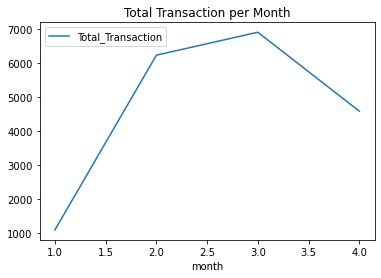

In [45]:
aa.plot(kind='line');
plt.title("Total Transaction per Month");

### Total unique total Item sold Per Month

In [46]:
bb = pd.DataFrame(df.groupby('month')['Item_description'].nunique())
bb.rename(columns= {'Receipt_No':'Total_unique_items'},inplace=True)
bb.style.background_gradient(cmap='Oranges')

,Item_description
month,
1,1350
2,3556
3,3730
4,4200


The above table shows the total number of unique items sold in each month. Here we can see that the items sold in the april belongs to maximum number of items types. this mean that the almost every transaction of april contain a new and different items. Also in January the unique items sold in january is 1350 and the total number of transactions are 1089, this mean that also in january, almost every single transaction contain a new different product. However in Feb and march the total number of transaction is around 6000 and the unique items sold are around 3000 this mean that more similiar products are sold in february and march. 

Let visualize them over plot

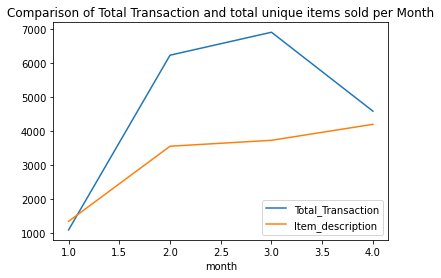

In [47]:
cc = pd.merge(aa,bb,on=aa.index)
cc = cc.rename(columns={'key_0':'month'}).set_index('month')
cc.plot(kind='line');
plt.title("Comparison of Total Transaction and total unique items sold per Month");

this plot justify our above analysis

### Most Frequently Sold Items

In [48]:
freq_df = pd.DataFrame(df['Item_description'].value_counts()).reset_index()
freq_df.columns = ['Items', 'frequency']

In [49]:
freq_df.head(20).style.background_gradient(cmap='Greens')

,Items,frequency
0,Aqua 1500ml(1x12x1500ml),2123
1,Non-Woven Bag PcsS,1635
2,Non-Woven Bag PcsM,1465
3,Aqua 600ml(1x24x600ml),1460
4,Chicken Leg Quarter/ Paha Besar,1255
5,Ikan Kembong,1007
6,Non-Woven Bag PcsL,506
7,Le Minerale 600ml,476
8,Weizhang Cake 1.5,359
9,Bawang Putih,353


Above plot shows the top 20 items that are mostly sold

In [50]:
import plotly.express as px

In [51]:
# to have a same origin
freq_df["all"] = "Top 30 Frequently Sold Items" 
# creating tree map using plotly
fig = px.treemap(freq_df.head(30), path=['all', "Items"], values='frequency',
                  color=freq_df["frequency"].head(30), hover_data=['Items'],
                  color_continuous_scale='Blues',
                )
# ploting the treemap
fig.show()

Above plot shows the top 30 product/items that are mostly sold.

### Least Frequently Sold Items

In [52]:
freq_df[['Items','frequency']].tail(20).style.background_gradient(cmap='Reds')

,Items,frequency
7721,Biore BF 600ml Lively Refresh,1
7722,Campbell's Soup Chunky Chicken Vegetable 505g(1x12x505g),1
7723,Campbell's Soup CL Creamy Chicken 500g(1x12x500g),1
7724,Nobre Naturissimos Salcichas 160g,1
7725,Mega Sardines In Natural Oil 155g(1x48x155g),1
7726,Edgell 4x125g Super Sweet Corn,1
7727,Emeron Hair vitamin Soft & Smoot,1
7728,SmartHeart Dog Creamy Treat Adult Chicken and Pumpkin 60gr,1
7729,Ovale FL Yam Beam 100ml,1
7730,Original Source Shower Gel Vanilla & Raspberry 250ml,1


Above plot shows the top 20 items that are rarely sold during the 4 month period

As the products that are only sold once or twice over the period of 4 month, we should remove from our analysis as thry didnot add any value to our analysis

In [53]:
least_sold_items = freq_df[freq_df['frequency']<10]['Items'].values.tolist()

In [54]:
df = df[~df['Item_description'].isin(least_sold_items)]

###  Most Important items in terms of Selling Patterns

To find the most important items that should always be in store, we will first filter out the the top 30 mostly sold products and check does they sold in every month, if they do that mean they are the items that should always be present in the store

for this we first need to create a week column

In [55]:
freq_items = freq_df["Items"].head(30).values.tolist()

In [56]:
freq_items_df = df[df['Item_description'].isin(freq_items)]
qq = pd.DataFrame(freq_items_df.groupby('Item_description')['month'].unique()).reset_index()
qq['total_month'] = qq['month'].str.len()
qq

,Item_description,month,total_month
0,Apple Fuji,"[1, 2, 3, 4]",4
1,Apple Pink Lady,"[1, 2, 3, 4]",4
2,Aqua 1500ml(1x12x1500ml),"[2, 3, 4]",3
3,Aqua 330ml,"[1, 2, 3, 4]",4
4,Aqua 600ml(1x24x600ml),"[2, 3, 4]",3
5,Aqua Fresca 1500ml(1x12x1500ml),"[2, 3, 4]",3
6,Aqua Gota 1500ml,"[1, 2, 3, 4]",4
7,Aqua Gota 600ml,"[1, 2, 3, 4]",4
8,Bawang Merah Kecil,"[1, 2, 3, 4]",4
9,Bawang Putih,"[1, 2, 3, 4]",4


The above table shows all of the top 30 items along with the weeks in which they sold

In [57]:
qq[qq['total_month']==4].style.background_gradient(cmap='Greens')

,Item_description,month,total_month
0,Apple Fuji,[1 2 3 4],4
1,Apple Pink Lady,[1 2 3 4],4
3,Aqua 330ml,[1 2 3 4],4
6,Aqua Gota 1500ml,[1 2 3 4],4
7,Aqua Gota 600ml,[1 2 3 4],4
8,Bawang Merah Kecil,[1 2 3 4],4
9,Bawang Putih,[1 2 3 4],4
10,Bokchoy,[1 2 3 4],4
11,Chicken Leg Quarter/ Paha Besar,[1 2 3 4],4
12,Chinese Cabbage,[1 2 3 4],4


The above 25 items are the items that are sold every week, so they should always be present in the store

In [58]:
qq.to_excel("item_weekly33.xlsx")

### Dividing Data into Periods

In [59]:
period_1 = df[df['month']==1]
period_2 = df[df['month']==2]
period_3 = df[df['month']==3]
period_4 = df[df['month']==4]

In [60]:
period_1.shape

(1943, 7)

In [61]:
period_2.shape

(11871, 7)

In [62]:
period_3.shape

(13469, 7)

In [63]:
period_4.shape

(11591, 7)

### Top Sold Products in terms of Each Period

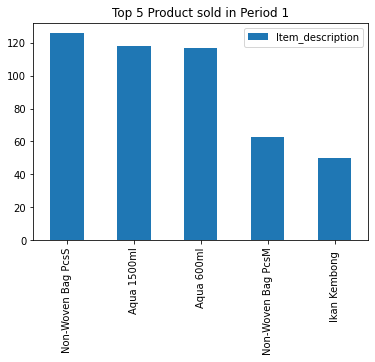

In [64]:
pd.DataFrame(period_1['Item_description'].value_counts().head()).plot(kind='bar');
plt.title('Top 5 Product sold in Period 1');

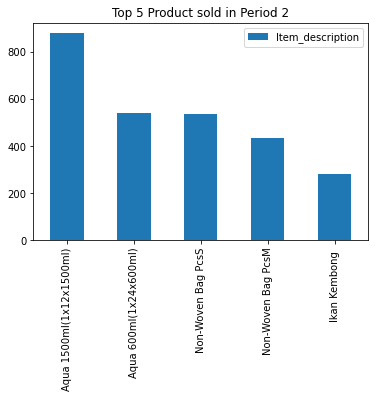

In [65]:
pd.DataFrame(period_2['Item_description'].value_counts().head()).plot(kind='bar');
plt.title('Top 5 Product sold in Period 2');

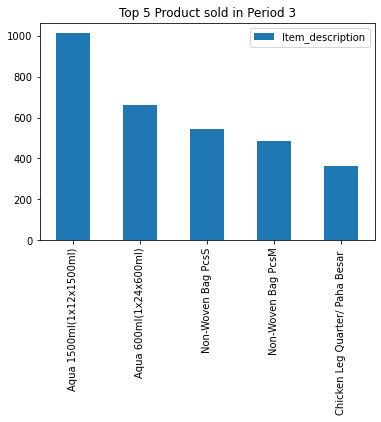

In [66]:
pd.DataFrame(period_3['Item_description'].value_counts().head()).plot(kind='bar');
plt.title('Top 5 Product sold in Period 3');

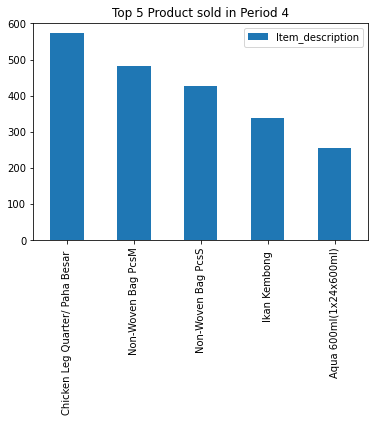

In [67]:
pd.DataFrame(period_4['Item_description'].value_counts().head()).plot(kind='bar');
plt.title('Top 5 Product sold in Period 4');

# Market Basket Analysis

After analyzing the each product individually we will now look at the relationships between these products

Process of Analysis Using (Market Basket Technique): 
- First we create the basket of products per member_numner. then  we use TransactionEncoder object to transform this dataset into an array format suitable for typical machine learning APIs. Via the fit method, the TransactionEncoder learns the unique labels in the dataset, and via the transform method, it transforms the input dataset (a Python list of lists) into a one-hot encoded NumPy boolean array. then convert it in to a Dataframe. Than we generate Frequent item set (products that are frequently bought together) with a chosen support threshold value. These support threshold value is used to choose those product subsets that has most occurred in the dataset.
- We set support threshold value to 0.01. that mean the occurrence of the product subset in the observed dataset should be at least 1%
- After that on the Basis of these frequent item set we defines rules that indicate the chances of the occurrence of the product subset in entire transaction. in the other words we can say that rules define how often the product subset will occur in the future. Rules does this on the basis of the support, confidence and lift values. the higher the support, confidence and lift value the higher the chance of product subset re-occurrence.


In [68]:
from itertools import permutations
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

#### Period 1

In [69]:
# list items by member IDs
transcation_id = period_1['Receipt_No'].unique()
items = [list(period_1.loc[period_1['Receipt_No'] == id, 'Item_description']) for id in transcation_id]
print(items[0])

['Spring Onion ', 'Spring Onion ', 'Spring Onion ', 'Spring Onion ', 'Spring Onion ']


In [70]:
# create a item matrix
TE = TransactionEncoder()
TE.fit(items)
item_transformed = TE.transform(items)
item_matrix = pd.DataFrame(item_transformed, columns = TE.columns_)
item_matrix.head()

,21G75 Adas Bintang 1Kg,21G76 Kayu Manis Batang 1Kg,21MJ4 Farmers Grange 208g,ABC Kacang Hijau 250ml,ABC Kecap 133ml Asin,ABC Kecap 135ml Manis,ABC Kecap 275ml manis,ABC Kecap 620ml Manis,ABC Sambal 135ml Asli,ABC Tomato 135ml,...,Xylitol 29g Stroberi,Xylitol 58g Bluberi,Xylitol 58g Breezy,Y1002 Coca-Cola 1.25L,Y140 Nutri Express 500ml,Y32 Red Bull 250ml,Y47 Vitaso Vanilla Soy Milk 250ml,Yakult 65ml 5s,You C1000 140ml Orange,You C1000 Lemon 140ml
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [71]:
# get the support value by Apriori algorithm
freq_items = apriori(item_matrix, min_support=0.003, use_colnames=True, max_len=2)
freq_items.sort_values(by = "support", ascending = False)

,support,itemsets
104,0.139381,(Non-Woven Bag PcsS)
5,0.130531,(Aqua 1500ml)
7,0.129425,(Aqua 600ml)
103,0.069690,(Non-Woven Bag PcsM)
102,0.036504,(Non-Woven Bag PcsL)
...,...,...
100,0.003319,(Nice Facial 250s)
99,0.003319,(Nestle Bear Brand 189ml)
95,0.003319,(Mie Sedaap Sambal Goreng)
94,0.003319,(Masako Sapi (12*9g))


the above table is the frequents itemset/ subset of items. 

In [72]:
# create a datafram with product support, confidence , and lift values
rules_1 = association_rules(freq_items, metric = "confidence", min_threshold = 0.1)
rules_1

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Apple Fuji ),(Bokchoy ),0.018805,0.024336,0.003319,0.176471,7.251337,0.002861,1.184735
1,(Bokchoy ),(Apple Fuji ),0.024336,0.018805,0.003319,0.136364,7.251337,0.002861,1.136120
2,(Ikan Kembong ),(Apple Fuji ),0.022124,0.018805,0.003319,0.150000,7.976471,0.002903,1.154347
3,(Apple Fuji ),(Ikan Kembong ),0.018805,0.022124,0.003319,0.176471,7.976471,0.002903,1.187421
4,(Apple Fuji ),(Non-Woven Bag PcsM),0.018805,0.069690,0.003319,0.176471,2.532213,0.002008,1.129662
...,...,...,...,...,...,...,...,...,...
81,(Sweet Cake $1.5),(Non-Woven Bag PcsS),0.008850,0.139381,0.003319,0.375000,2.690476,0.002085,1.376991
82,(Weizhang Cake 1.5),(Non-Woven Bag PcsS),0.019912,0.139381,0.003319,0.166667,1.195767,0.000543,1.032743
83,(You C1000 Lemon 140ml),(Non-Woven Bag PcsS),0.011062,0.139381,0.003319,0.300000,2.152381,0.001777,1.229456
84,(You C1000 140ml Orange),(You C1000 Lemon 140ml),0.016593,0.011062,0.003319,0.200000,18.080000,0.003135,1.236173


These are the rules

1. support is used to measure the abundance or frequency (often interpreted as significance or importance) of an item set in a dataset. its value range is 0 to 1. here because of huge numbers of product we can see that support values are below 0.1.
2. The confidence of a rule is the probability of seeing the consequent in a transaction given that it also contains the antecedent. it ranges from 0 to 1.
3. The lift metric is commonly used to measure how much more often the antecedent and consequent of a rule occur together than we would expect if they were statistically independent. If antecedent and consequent are independent, the Lift score will be exactly 1.
4. Leverage computes the difference between the observed frequency of A and C appearing together and the frequency that would be expected if A and C were independent. A leverage value of 0 indicates independence.
5. A high conviction value means that the consequent is highly depending on the antecedent.


In [73]:
rules_1['antecedents'] = rules_1['antecedents'].apply(lambda a: ', '.join(list(a)))
rules_1['consequents'] = rules_1['consequents'].apply(lambda a: ', '.join(list(a)))
rules_1.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,Apple Fuji,Bokchoy,0.018805,0.024336,0.003319,0.176471,7.251337,0.002861,1.184735
1,Bokchoy,Apple Fuji,0.024336,0.018805,0.003319,0.136364,7.251337,0.002861,1.136120
2,Ikan Kembong,Apple Fuji,0.022124,0.018805,0.003319,0.150000,7.976471,0.002903,1.154347
3,Apple Fuji,Ikan Kembong,0.018805,0.022124,0.003319,0.176471,7.976471,0.002903,1.187421
4,Apple Fuji,Non-Woven Bag PcsM,0.018805,0.069690,0.003319,0.176471,2.532213,0.002008,1.129662
5,Apple Pink Lady,Fresh Grape Red China (22-26cm),0.018805,0.021018,0.006637,0.352941,16.792570,0.006242,1.512973
6,Fresh Grape Red China (22-26cm),Apple Pink Lady,0.021018,0.018805,0.006637,0.315789,16.792570,0.006242,1.434054
7,Apple Pink Lady,Non-Woven Bag PcsL,0.018805,0.036504,0.005531,0.294118,8.057041,0.004844,1.364952
8,Non-Woven Bag PcsL,Apple Pink Lady,0.036504,0.018805,0.005531,0.151515,8.057041,0.004844,1.156408
9,Apple Pink Lady,Non-Woven Bag PcsM,0.018805,0.069690,0.004425,0.235294,3.376284,0.003114,1.216559


/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/rcmod.py:400: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/rcmod.py:400: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/matrix.py:302: MatplotlibDeprecationWarning:

Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call gri

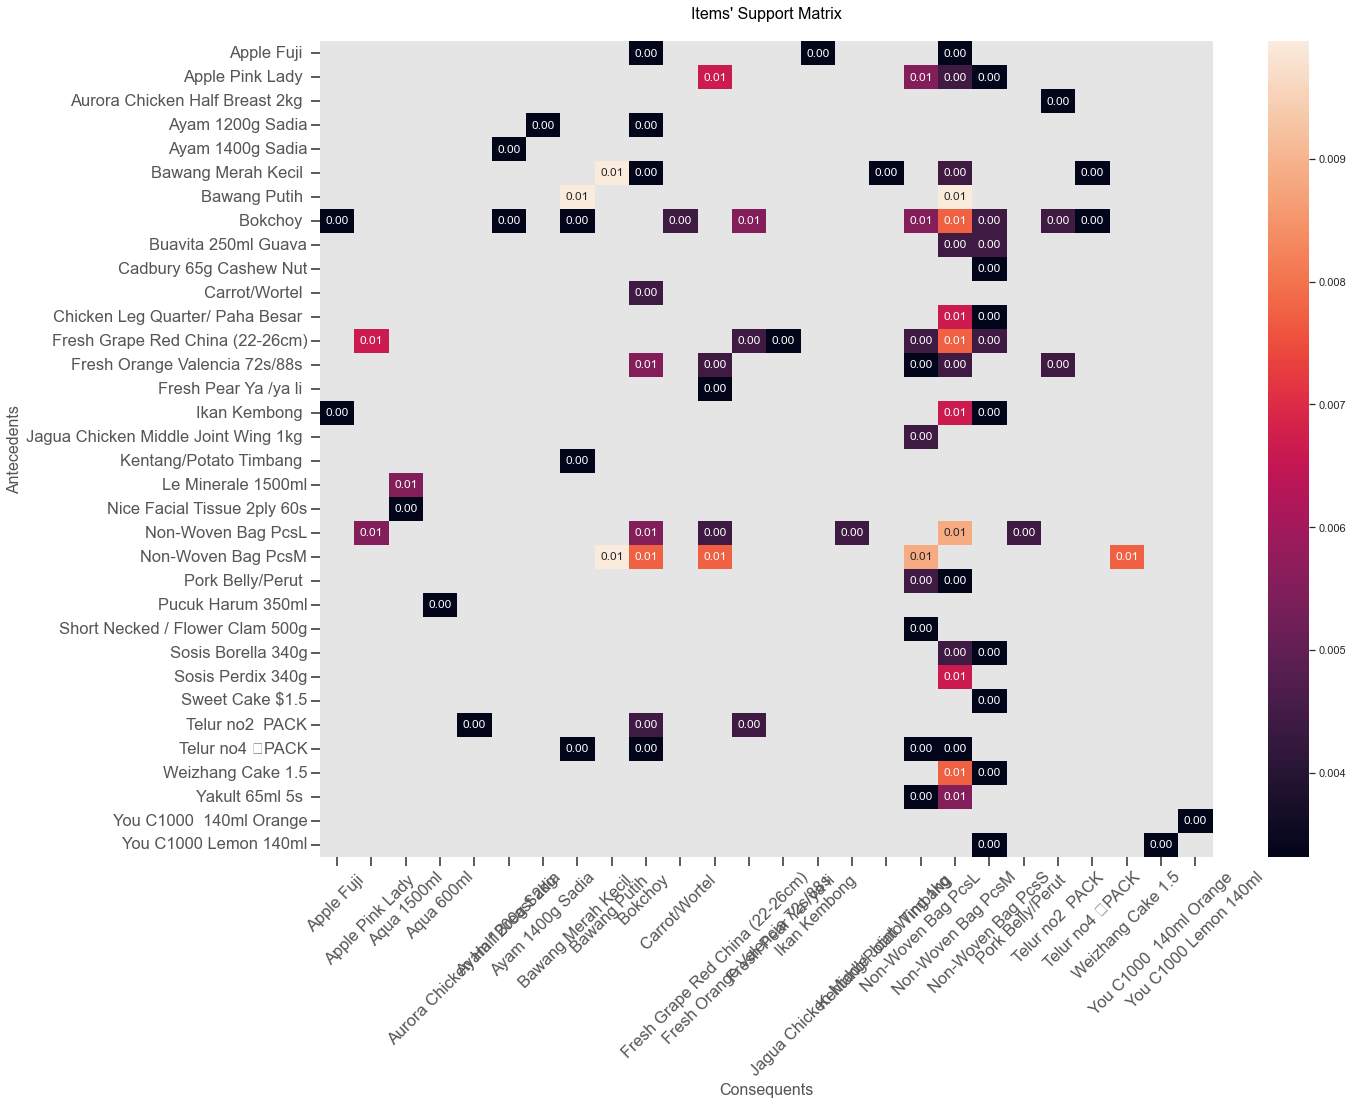

In [74]:
# plot a heatmap to know how strong the association is based on lift values
pivot_support = rules_1.pivot(index='antecedents', columns='consequents', values='support')

sns.set_context("talk")
plt.style.use('ggplot')
plt.subplots(figsize=(20, 15))
sns.set()
ax = sns.heatmap(data=pivot_support, annot=True, fmt='.2f', cbar=True)
plt.title("Items' Support Matrix", fontsize=16, y=1.02)
ax.set_xlabel("Consequents",fontsize=16)
ax.set_ylabel("Antecedents",fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show() 

Here we can see how the relationships values of products which are highly sold together.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/rcmod.py:400: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:130: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:130: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



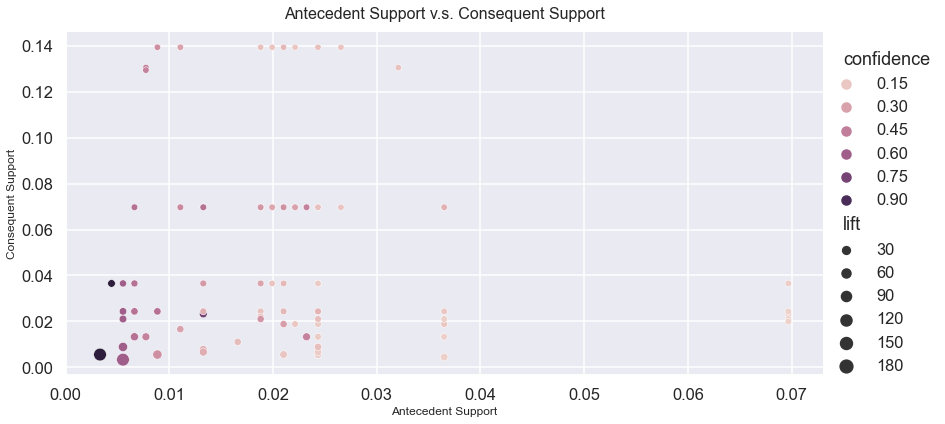

In [75]:
# take a quick look at the distribution of the product combination
sns.set_context("talk")
sns.relplot(x='antecedent support', y='consequent support', data=rules_1, 
            size='lift', hue='confidence', height=6, aspect=2)
plt.title("Antecedent Support v.s. Consequent Support", fontsize=16, y=1.02)
plt.xlabel('Antecedent Support', fontsize=12)
plt.ylabel('Consequent Support', fontsize=12)
plt.show()

In [76]:
# the comparison between the sopport and confidence of all combinations
fig = px.scatter(rules_1, x='support', y='confidence', 
                 color='lift', hover_data=['antecedents', 'confidence'],
                 labels={
                     "support": "Support",
                     "confidence": "Confidence",
                     'lift': 'Lift'
                 },
                title="Support v.s. Confidence")
fig.update_layout(title_x=0.5, title_y=0.86)
fig.show()

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/plotly/io/_renderers.py:396: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/plotly/io/_renderers.py:396: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



#### Period 2

In [77]:
# list items by member IDs
transcation_id = period_2['Receipt_No'].unique()
items = [list(period_2.loc[period_2['Receipt_No'] == id, 'Item_description']) for id in transcation_id]
print(items[0])

['R.LA ']


In [78]:
# create a item matrix
TE = TransactionEncoder()
TE.fit(items)
item_transformed = TE.transform(items)
item_matrix = pd.DataFrame(item_transformed, columns = TE.columns_)
item_matrix.head()

,(B2)Gresh Orange 300ml(1x24),21G75 Adas Bintang 1Kg,21G76 Kayu Manis Batang 1Kg,21L44 LuJie XiMei Plum 108g,21L98 Sunflower Seeds 150g,21MJ4 Farmers Grange 208g,A&W Sarsaparilla 330ml(1x24x330ml),ABC Guava Juice 250ml,ABC Juice 250ml Lychee,ABC Juice 250ml Mango,...,Y54 Green Tea500ml(1x15),Y55 Iced Red Tea500ml(1x15),Y56 KanShiFu 1L BinHon Cha(1x12),Y7 Breakfast milk250ml(1x24x250ml),Yakult 65ml 5s,You C1000 140ml Orange,You C1000 Orange 140ml,You C1000 Lemon 140ml,Zuperrr Keju Chocolate 20.5g(1x80x20.5g),lindt Excel Orange 100gx20
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [79]:
# get the support value by Apriori algorithm
freq_items = apriori(item_matrix, min_support=0.003, use_colnames=True, max_len=2)
freq_items.sort_values(by = "support", ascending = False)

,support,itemsets
5,0.159942,(Aqua 1500ml(1x12x1500ml))
7,0.098328,(Aqua 600ml(1x24x600ml))
72,0.097964,(Non-Woven Bag PcsS)
71,0.079426,(Non-Woven Bag PcsM)
57,0.032352,(Le Minerale 600ml)
...,...,...
120,0.003090,"(Country Choice 250ml Jambu(1x24), Aqua 1500ml..."
125,0.003090,"(Dodo Fish Ball 200g(1x30x200g), Ayam 1200g Sa..."
50,0.003090,(Kratingdaeng Btl 150ml)
12,0.003090,(Audian Furak Mie $1.80)


the above table is the frequents itemset/ subset of items. 

In [80]:
# create a datafram with product support, confidence , and lift values
rules_2 = association_rules(freq_items, metric = "confidence", min_threshold = 0.1)
rules_2

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Country Choice 250ml Jambu(1x24)),(Aqua 1500ml(1x12x1500ml)),0.018175,0.159942,0.003090,0.170000,1.062886,0.000183,1.012118
1,(Le Minerale 1500ml),(Aqua 1500ml(1x12x1500ml)),0.031261,0.159942,0.004180,0.133721,0.836060,-0.000820,0.969732
2,(You C1000 140ml Orange),(Aqua 1500ml(1x12x1500ml)),0.020356,0.159942,0.004180,0.205357,1.283949,0.000924,1.057152
3,(Ayam 1400g Sadia),(Ayam 1200g Sadia),0.004544,0.004362,0.003817,0.840000,192.570000,0.003797,6.222737
4,(Ayam 1200g Sadia),(Ayam 1400g Sadia),0.004362,0.004544,0.003817,0.875000,192.570000,0.003797,7.963650
5,(Dodo Fish Ball 200g(1x30x200g)),(Ayam 1200g Sadia),0.004726,0.004362,0.003090,0.653846,149.894231,0.003069,2.876287
6,(Ayam 1200g Sadia),(Dodo Fish Ball 200g(1x30x200g)),0.004362,0.004726,0.003090,0.708333,149.894231,0.003069,3.412370
7,(Ayam 1200g Sadia),(Fresh Orange Valencia 72s/88s ),0.004362,0.013631,0.003453,0.791667,58.076667,0.003394,4.734569
8,(Fresh Orange Valencia 72s/88s ),(Ayam 1200g Sadia),0.013631,0.004362,0.003453,0.253333,58.076667,0.003394,1.333444
9,(Telur no2 PACK),(Ayam 1200g Sadia),0.008906,0.004362,0.003453,0.387755,88.892857,0.003414,1.626209


These are the rules

In [81]:
rules_2['antecedents'] = rules_2['antecedents'].apply(lambda a: ', '.join(list(a)))
rules_2['consequents'] = rules_2['consequents'].apply(lambda a: ', '.join(list(a)))
rules_2.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,Country Choice 250ml Jambu(1x24),Aqua 1500ml(1x12x1500ml),0.018175,0.159942,0.003090,0.170000,1.062886,0.000183,1.012118
1,Le Minerale 1500ml,Aqua 1500ml(1x12x1500ml),0.031261,0.159942,0.004180,0.133721,0.836060,-0.000820,0.969732
2,You C1000 140ml Orange,Aqua 1500ml(1x12x1500ml),0.020356,0.159942,0.004180,0.205357,1.283949,0.000924,1.057152
3,Ayam 1400g Sadia,Ayam 1200g Sadia,0.004544,0.004362,0.003817,0.840000,192.570000,0.003797,6.222737
4,Ayam 1200g Sadia,Ayam 1400g Sadia,0.004362,0.004544,0.003817,0.875000,192.570000,0.003797,7.963650


/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/rcmod.py:400: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/rcmod.py:400: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/matrix.py:302: MatplotlibDeprecationWarning:

Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call gri

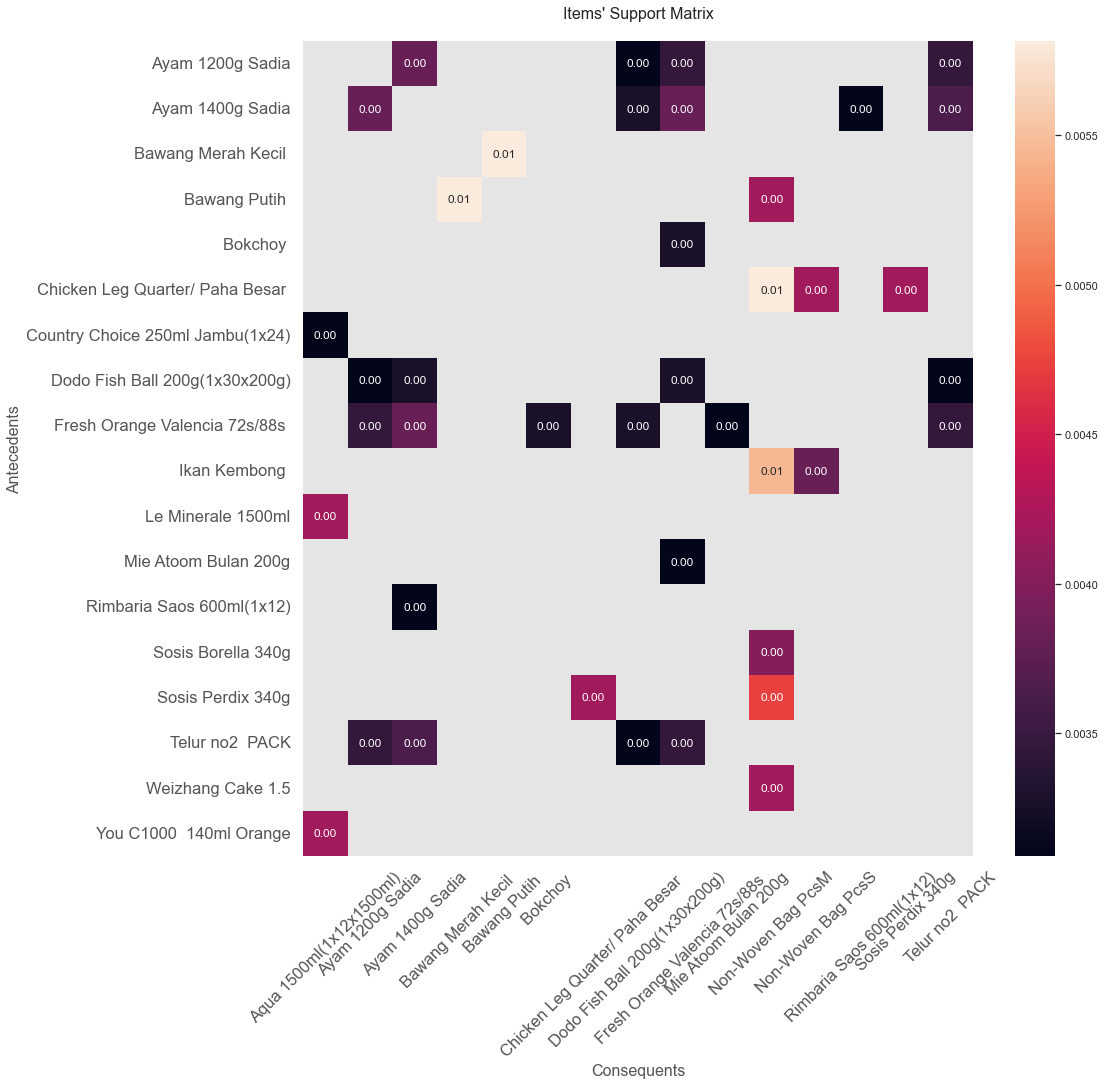

In [82]:
# plot a heatmap to know how strong the association is based on lift values
pivot_support = rules_2.pivot(index='antecedents', columns='consequents', values='support')

sns.set_context("talk")
plt.style.use('ggplot')
plt.subplots(figsize=(15, 15))
sns.set()
ax = sns.heatmap(data=pivot_support, annot=True, fmt='.2f', cbar=True)
plt.title("Items' Support Matrix", fontsize=16, y=1.02)
ax.set_xlabel("Consequents",fontsize=16)
ax.set_ylabel("Antecedents",fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show() 

Here we can see how the relationships values of products which are highly sold together.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/rcmod.py:400: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:130: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:130: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



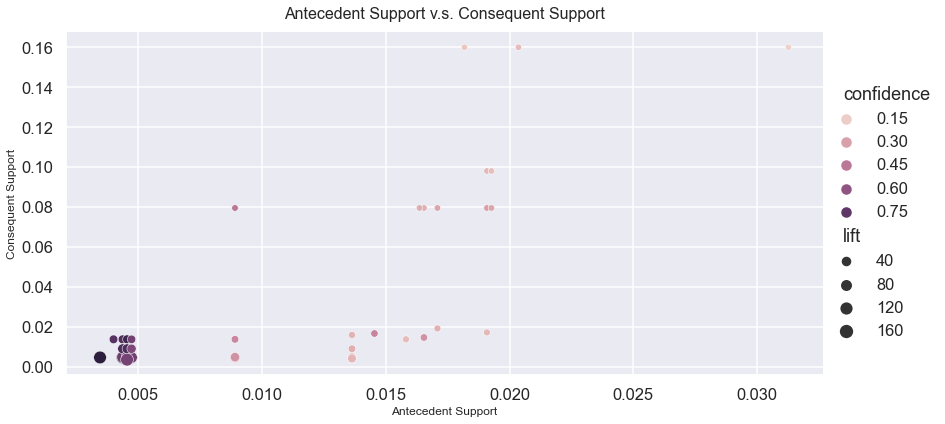

In [83]:
# take a quick look at the distribution of the product combination
sns.set_context("talk")
sns.relplot(x='antecedent support', y='consequent support', data=rules_2, 
            size='lift', hue='confidence', height=6, aspect=2)
plt.title("Antecedent Support v.s. Consequent Support", fontsize=16, y=1.02)
plt.xlabel('Antecedent Support', fontsize=12)
plt.ylabel('Consequent Support', fontsize=12)
plt.show()

In [84]:
# the comparison between the sopport and confidence of all combinations
fig = px.scatter(rules_2, x='support', y='confidence', 
                 color='lift', hover_data=['antecedents', 'confidence'],
                 labels={
                     "support": "Support",
                     "confidence": "Confidence",
                     'lift': 'Lift'
                 },
                title="Support v.s. Confidence")
fig.update_layout(title_x=0.5, title_y=0.86)
fig.show()

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/plotly/io/_renderers.py:396: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/plotly/io/_renderers.py:396: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



#### Period 3

In [85]:
# list items by member IDs
transcation_id = period_3['Receipt_No'].unique()
items = [list(period_3.loc[period_3['Receipt_No'] == id, 'Item_description']) for id in transcation_id]
print(items[0])

['Buavita 250ml Guava(1x24x250ml)', 'Buavita 250ml Orange(1x24x250ml)']


In [86]:
# create a item matrix
TE = TransactionEncoder()
TE.fit(items)
item_transformed = TE.transform(items)
item_matrix = pd.DataFrame(item_transformed, columns = TE.columns_)
item_matrix.head()

,(B2) Gresh Orange 300ml(1x24),(B2) Y56 KanShiFu 1L BinHon Cha(1x12),(B2)Australia's Own Strawberry 200ml(1x24),(B2)Gresh Orange 300ml(1x24),21G75 Adas Bintang 1Kg,21G76 Kayu Manis Batang 1Kg,21L44 LuJie XiMei Plum 108g,21L98 Sunflower Seeds 150g,21MJ4 Farmers Grange 208g,A&W Sarsaparilla 330ml(1x24x330ml),...,Y55 Iced Red Tea500ml(1x15),Y56 KanShiFu 1L BinHon Cha(1x12),Y57 Jasmine Honey Tea 500ml (1x15),Y7 Breakfast milk250ml(1x24x250ml),Yakult 65ml 5s,You C1000 Orange 140ml,You C1000 Lemon 140ml,Yupi GummiPizza/SweetHeart,Yupi Sweet Heart 15g,lindt Excel Orange 100gx20
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [87]:
# get the support value by Apriori algorithm
freq_items = apriori(item_matrix, min_support=0.003, use_colnames=True, max_len=2)
freq_items.sort_values(by = "support", ascending = False)

,support,itemsets
5,0.164019,(Aqua 1500ml(1x12x1500ml))
7,0.107455,(Aqua 600ml(1x24x600ml))
79,0.087844,(Non-Woven Bag PcsS)
78,0.078282,(Non-Woven Bag PcsM)
64,0.040194,(Le Minerale 600ml)
...,...,...
125,0.003079,(Weizhang Cake 2.00)
42,0.003079,(Disposable Mask 3D 10s /)
107,0.003079,(Tango Waffle Cranch Chox 35g(1x60x35g))
86,0.003079,(Qtela 60g Barbeque(1x30))


the above table is the frequents itemset/ subset of items. 

In [88]:
# create a datafram with product support, confidence , and lift values
rules_3 = association_rules(freq_items, metric = "confidence", min_threshold = 0.08)
rules_3

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Apple Fuji ),(Non-Woven Bag PcsM),0.018963,0.078282,0.003079,0.162393,2.074463,0.001595,1.100418
1,(Apple Pink Lady ),(Non-Woven Bag PcsM),0.011669,0.078282,0.003890,0.333333,4.258109,0.002976,1.382577
2,(Aqua 600ml(1x24x600ml)),(Aqua 1500ml(1x12x1500ml)),0.107455,0.164019,0.009400,0.087481,0.533358,-0.008224,0.916124
3,(Ultramilk Coklat 125ml),(Aqua 1500ml(1x12x1500ml)),0.013290,0.164019,0.004052,0.304878,1.858792,0.001872,1.202639
4,(Dodo Fish Ball 200g(1x30x200g)),(Ayam 1200g Sadia),0.003890,0.004376,0.003241,0.833333,190.432099,0.003224,5.973744
5,(Ayam 1200g Sadia),(Dodo Fish Ball 200g(1x30x200g)),0.004376,0.003890,0.003241,0.740741,190.432099,0.003224,3.842139
6,(Bawang Putih ),(Bawang Merah Kecil ),0.017666,0.010373,0.005673,0.321101,30.956135,0.005489,1.457694
7,(Bawang Merah Kecil ),(Bawang Putih ),0.010373,0.017666,0.005673,0.546875,30.956135,0.005489,2.167909
8,(Bawang Putih ),(Non-Woven Bag PcsM),0.017666,0.078282,0.003890,0.220183,2.812696,0.002507,1.181968
9,(Chicken Leg Quarter/ Paha Besar ),(Ikan Kembong ),0.018314,0.026094,0.005511,0.300885,11.530809,0.005033,1.393055


In [89]:
rules_3.to_excel("rules_3.xlsx")

These are the rules

In [90]:
rules_3['antecedents'] = rules_3['antecedents'].apply(lambda a: ', '.join(list(a)))
rules_3['consequents'] = rules_3['consequents'].apply(lambda a: ', '.join(list(a)))
rules_3.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,Apple Fuji,Non-Woven Bag PcsM,0.018963,0.078282,0.003079,0.162393,2.074463,0.001595,1.100418
1,Apple Pink Lady,Non-Woven Bag PcsM,0.011669,0.078282,0.003890,0.333333,4.258109,0.002976,1.382577
2,Aqua 600ml(1x24x600ml),Aqua 1500ml(1x12x1500ml),0.107455,0.164019,0.009400,0.087481,0.533358,-0.008224,0.916124
3,Ultramilk Coklat 125ml,Aqua 1500ml(1x12x1500ml),0.013290,0.164019,0.004052,0.304878,1.858792,0.001872,1.202639
4,Dodo Fish Ball 200g(1x30x200g),Ayam 1200g Sadia,0.003890,0.004376,0.003241,0.833333,190.432099,0.003224,5.973744


/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/rcmod.py:400: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/rcmod.py:400: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/matrix.py:302: MatplotlibDeprecationWarning:

Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call gri

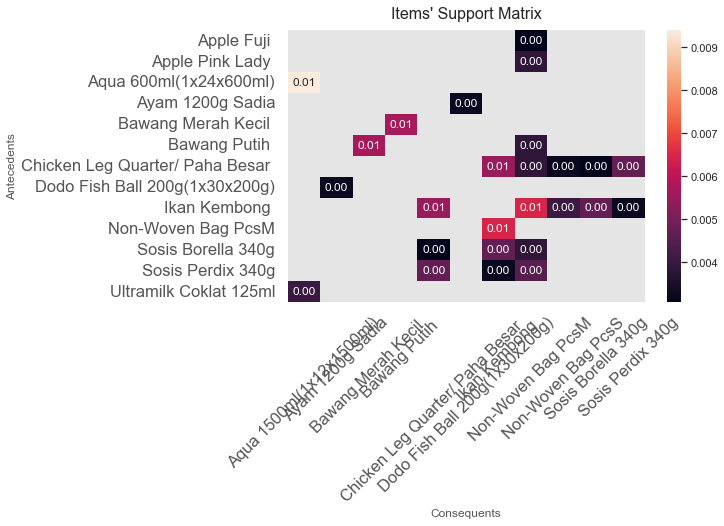

In [91]:
# plot a heatmap to know how strong the association is based on lift values
pivot_support = rules_3.pivot(index='antecedents', columns='consequents', values='support')

sns.set_context("talk")
plt.style.use('ggplot')
plt.subplots(figsize=(8, 5))
sns.set()
ax = sns.heatmap(data=pivot_support, annot=True, fmt='.2f', cbar=True)
plt.title("Items' Support Matrix", fontsize=16, y=1.02)
ax.set_xlabel("Consequents",fontsize=12)
ax.set_ylabel("Antecedents",fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show() 

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/rcmod.py:400: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:130: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:130: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



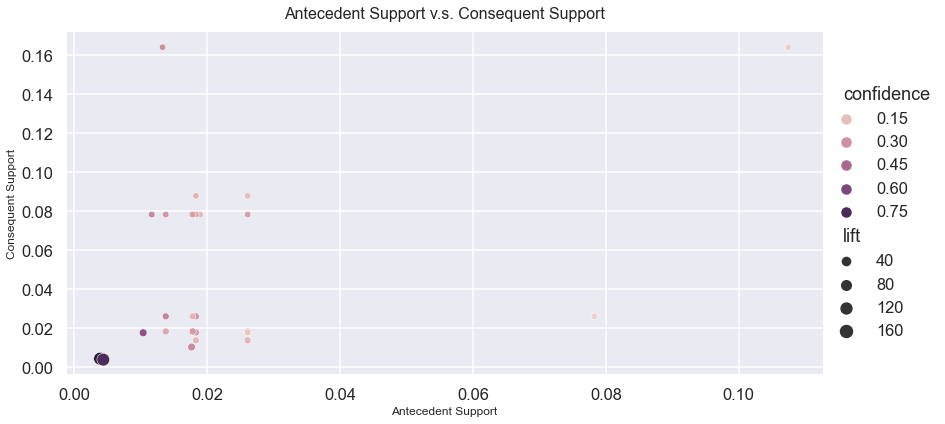

In [92]:
# take a quick look at the distribution of the product combination
sns.set_context("talk")
sns.relplot(x='antecedent support', y='consequent support', data=rules_3, 
            size='lift', hue='confidence', height=6, aspect=2)
plt.title("Antecedent Support v.s. Consequent Support", fontsize=16, y=1.02)
plt.xlabel('Antecedent Support', fontsize=12)
plt.ylabel('Consequent Support', fontsize=12)
plt.show()

In [93]:
# the comparison between the sopport and confidence of all combinations
fig = px.scatter(rules_3, x='support', y='confidence', 
                 color='lift', hover_data=['antecedents', 'confidence'],
                 labels={
                     "support": "Support",
                     "confidence": "Confidence",
                     'lift': 'Lift'
                 },
                title="Support v.s. Confidence")
fig.update_layout(title_x=0.5, title_y=0.86)
fig.show()

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/plotly/io/_renderers.py:396: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/plotly/io/_renderers.py:396: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



#### Period 4

In [94]:
# list items by member IDs
transcation_id = period_4['Receipt_No'].unique()
items = [list(period_4.loc[period_4['Receipt_No'] == id, 'Item_description']) for id in transcation_id]
print(items[0])

['Indomilk Kids 115ml Coklat']


In [95]:
# create a item matrix
TE = TransactionEncoder()
TE.fit(items)
item_transformed = TE.transform(items)
item_matrix = pd.DataFrame(item_transformed, columns = TE.columns_)
item_matrix.head()

,(B2) Gresh Orange 300ml(1x24),(B2) Y56 KanShiFu 1L BinHon Cha(1x12),(B2)Australia's Own Strawberry 200ml(1x24),21G75 Adas Bintang 1Kg,21G76 Kayu Manis Batang 1Kg,ABC Juice 250ml Lychee,ABC Juice 250ml Mango,ABC Kacang Hijau 250ml,ABC Kecap 133ml Asin,ABC Kecap 135ml Manis,...,Y54 Green Tea500ml(1x15),Y55 Iced Red Tea500ml(1x15),Y57 Jasmine Honey Tea 500ml (1x15),Yakult 65ml 5s,You C1000 Orange 140ml,You C1000 Lemon 140ml,Yupi GummiPizza/SweetHeart,Yupi Sweet Heart 15g,Zuperrr Keju Chocolate 20.5g(1x80x20.5g),lindt Excel Orange 100gx20
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [96]:
# get the support value by Apriori algorithm
freq_items = apriori(item_matrix, min_support=0.005, use_colnames=True, max_len=2)
freq_items.sort_values(by = "support", ascending = False)

,support,itemsets
75,0.124806,(Non-Woven Bag PcsM)
76,0.110823,(Non-Woven Bag PcsS)
7,0.066287,(Aqua 600ml(1x24x600ml))
74,0.061885,(Non-Woven Bag PcsL)
5,0.059814,(Aqua 1500ml(1x12x1500ml))
...,...,...
69,0.005179,(Magnum Almond)
58,0.005179,(Gula Pasir 5kg )
122,0.005179,"(Sosis Perdix 340g, Ikan Kembong )"
86,0.005179,(Selection Facial 50g Cotton)


the above table is the frequents itemset/ subset of items. 

In [97]:
# create a datafram with product support, confidence , and lift values
rules_4 = association_rules(freq_items, metric = "confidence", min_threshold = 0.1)
rules_4

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(Bawang Putih ),(Bawang Merah Kecil ),0.030813,0.031072,0.017866,0.579832,18.660924,0.016909,2.306049
1,(Bawang Merah Kecil ),(Bawang Putih ),0.031072,0.030813,0.017866,0.575000,18.660924,0.016909,2.280440
2,(Bawang Merah Kecil ),(Non-Woven Bag PcsM),0.031072,0.124806,0.007768,0.250000,2.003112,0.003890,1.166926
3,(Bawang Putih ),(Chicken Leg Quarter/ Paha Besar ),0.030813,0.041688,0.005697,0.184874,4.434678,0.004412,1.175661
4,(Chicken Leg Quarter/ Paha Besar ),(Bawang Putih ),0.041688,0.030813,0.005697,0.136646,4.434678,0.004412,1.122583
5,(Bawang Putih ),(Kentang/Potato Timbang ),0.030813,0.025893,0.006214,0.201681,7.788908,0.005417,1.220197
6,(Kentang/Potato Timbang ),(Bawang Putih ),0.025893,0.030813,0.006214,0.240000,7.788908,0.005417,1.275246
7,(Bawang Putih ),(Non-Woven Bag PcsL),0.030813,0.061885,0.005697,0.184874,2.987377,0.003790,1.150883
8,(Bawang Putih ),(Non-Woven Bag PcsM),0.030813,0.124806,0.007509,0.243697,1.952613,0.003663,1.157201
9,(Bokchoy ),(Non-Woven Bag PcsL),0.029518,0.061885,0.005438,0.184211,2.976657,0.003611,1.149947


These are the rules

In [98]:
rules_4['antecedents'] = rules_4['antecedents'].apply(lambda a: ', '.join(list(a)))
rules_4['consequents'] = rules_4['consequents'].apply(lambda a: ', '.join(list(a)))
rules_4.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,Bawang Putih,Bawang Merah Kecil,0.030813,0.031072,0.017866,0.579832,18.660924,0.016909,2.306049
1,Bawang Merah Kecil,Bawang Putih,0.031072,0.030813,0.017866,0.575000,18.660924,0.016909,2.280440
2,Bawang Merah Kecil,Non-Woven Bag PcsM,0.031072,0.124806,0.007768,0.250000,2.003112,0.003890,1.166926
3,Bawang Putih,Chicken Leg Quarter/ Paha Besar,0.030813,0.041688,0.005697,0.184874,4.434678,0.004412,1.175661
4,Chicken Leg Quarter/ Paha Besar,Bawang Putih,0.041688,0.030813,0.005697,0.136646,4.434678,0.004412,1.122583


/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/rcmod.py:400: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/rcmod.py:400: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/matrix.py:302: MatplotlibDeprecationWarning:

Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call gri

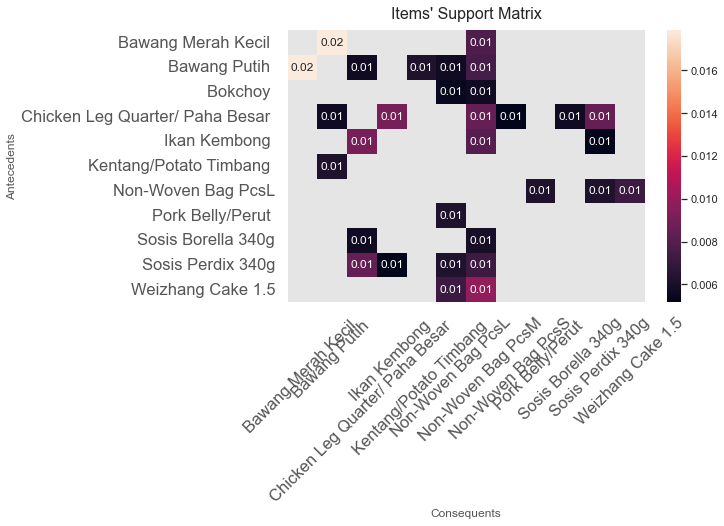

In [99]:
# plot a heatmap to know how strong the association is based on lift values
pivot_support = rules_4.pivot(index='antecedents', columns='consequents', values='support')

sns.set_context("talk")
plt.style.use('ggplot')
plt.subplots(figsize=(8, 5))
sns.set()
ax = sns.heatmap(data=pivot_support, annot=True, fmt='.2f', cbar=True)
plt.title("Items' Support Matrix", fontsize=16, y=1.02)
ax.set_xlabel("Consequents",fontsize=12)
ax.set_ylabel("Antecedents",fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show() 

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/rcmod.py:400: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/setuptools/_distutils/version.py:351: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:130: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:130: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



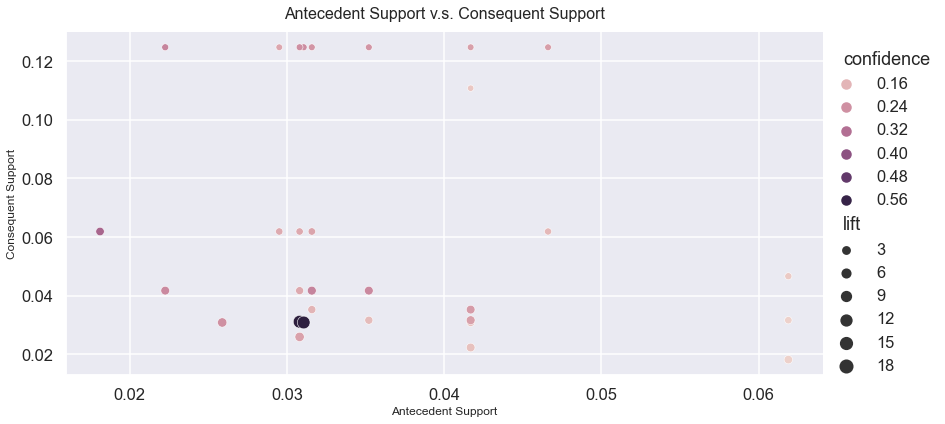

In [100]:
# take a quick look at the distribution of the product combination
sns.set_context("talk")
sns.relplot(x='antecedent support', y='consequent support', data=rules_4, 
            size='lift', hue='confidence', height=6, aspect=2)
plt.title("Antecedent Support v.s. Consequent Support", fontsize=16, y=1.02)
plt.xlabel('Antecedent Support', fontsize=12)
plt.ylabel('Consequent Support', fontsize=12)
plt.show()

In [101]:
# the comparison between the sopport and confidence of all combinations
fig = px.scatter(rules_4, x='support', y='confidence', 
                 color='lift', hover_data=['antecedents', 'confidence'],
                 labels={
                     "support": "Support",
                     "confidence": "Confidence",
                     'lift': 'Lift'
                 },
                title="Support v.s. Confidence")
fig.update_layout(title_x=0.5, title_y=0.86)
fig.show()

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/plotly/io/_renderers.py:396: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/plotly/io/_renderers.py:396: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



### Compare Support and Confidence for Each Period

In [102]:
period = [1,2,3,4]
support =[0.003,0.003, 0.003, 0.005]
confidence = [0.1, 0.1, 0.08, 0.1 ]
no_of_rules = [86,41,26, 31]
com = pd.DataFrame(period,columns=['period'])
com['Min_Support'] = support
com['Min_Confidence'] = confidence
com['Number of Rules'] = no_of_rules

In [103]:
com

,period,Min_Support,Min_Confidence,Number of Rules
0,1,0.003,0.10,86
1,2,0.003,0.10,41
2,3,0.003,0.08,26
3,4,0.005,0.10,31


In [104]:
rules_1.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,Apple Fuji,Bokchoy,0.018805,0.024336,0.003319,0.176471,7.251337,0.002861,1.184735
1,Bokchoy,Apple Fuji,0.024336,0.018805,0.003319,0.136364,7.251337,0.002861,1.136120
2,Ikan Kembong,Apple Fuji,0.022124,0.018805,0.003319,0.150000,7.976471,0.002903,1.154347
3,Apple Fuji,Ikan Kembong,0.018805,0.022124,0.003319,0.176471,7.976471,0.002903,1.187421
4,Apple Fuji,Non-Woven Bag PcsM,0.018805,0.069690,0.003319,0.176471,2.532213,0.002008,1.129662


In [105]:
rules_2.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,Country Choice 250ml Jambu(1x24),Aqua 1500ml(1x12x1500ml),0.018175,0.159942,0.003090,0.170000,1.062886,0.000183,1.012118
1,Le Minerale 1500ml,Aqua 1500ml(1x12x1500ml),0.031261,0.159942,0.004180,0.133721,0.836060,-0.000820,0.969732
2,You C1000 140ml Orange,Aqua 1500ml(1x12x1500ml),0.020356,0.159942,0.004180,0.205357,1.283949,0.000924,1.057152
3,Ayam 1400g Sadia,Ayam 1200g Sadia,0.004544,0.004362,0.003817,0.840000,192.570000,0.003797,6.222737
4,Ayam 1200g Sadia,Ayam 1400g Sadia,0.004362,0.004544,0.003817,0.875000,192.570000,0.003797,7.963650


In [106]:
rules_3.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,Apple Fuji,Non-Woven Bag PcsM,0.018963,0.078282,0.003079,0.162393,2.074463,0.001595,1.100418
1,Apple Pink Lady,Non-Woven Bag PcsM,0.011669,0.078282,0.003890,0.333333,4.258109,0.002976,1.382577
2,Aqua 600ml(1x24x600ml),Aqua 1500ml(1x12x1500ml),0.107455,0.164019,0.009400,0.087481,0.533358,-0.008224,0.916124
3,Ultramilk Coklat 125ml,Aqua 1500ml(1x12x1500ml),0.013290,0.164019,0.004052,0.304878,1.858792,0.001872,1.202639
4,Dodo Fish Ball 200g(1x30x200g),Ayam 1200g Sadia,0.003890,0.004376,0.003241,0.833333,190.432099,0.003224,5.973744


In [107]:
rules_4.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,Bawang Putih,Bawang Merah Kecil,0.030813,0.031072,0.017866,0.579832,18.660924,0.016909,2.306049
1,Bawang Merah Kecil,Bawang Putih,0.031072,0.030813,0.017866,0.575000,18.660924,0.016909,2.280440
2,Bawang Merah Kecil,Non-Woven Bag PcsM,0.031072,0.124806,0.007768,0.250000,2.003112,0.003890,1.166926
3,Bawang Putih,Chicken Leg Quarter/ Paha Besar,0.030813,0.041688,0.005697,0.184874,4.434678,0.004412,1.175661
4,Chicken Leg Quarter/ Paha Besar,Bawang Putih,0.041688,0.030813,0.005697,0.136646,4.434678,0.004412,1.122583


### Overall Variability of Association Rules 

5. Create an item matrix
6. Dived a transaction data in to 4 period (number of transaction and Item for each Period)
7. Get a support, confidence and lift value for all item with Apriori Algorithms.
8. Generating Association Rules with apriori algorithm.
9. Make a comparison between the support and confidence and support and all combination.
10. Apply overall variability of association rule for 4 different period to find important rules


Finding common Rules present in all 4 period

In [108]:
rules_1_2 = pd.merge(rules_1,rules_2,on=['antecedents','consequents'])
rules_1_2 = rules_1_2[['antecedents','consequents','confidence_x','lift_x','confidence_y','lift_y']]
rules_1_2.rename(columns={'confidence_x':'confidence_1','lift_x':'lift_1','confidence_y':'confidence_2','lift_y':'lift_2'},inplace=True)

In [109]:
rules_1_2

,antecedents,consequents,confidence_1,lift_1,confidence_2,lift_2
0,Ayam 1400g Sadia,Ayam 1200g Sadia,1.000000,180.800000,0.840000,192.570000
1,Ayam 1200g Sadia,Ayam 1400g Sadia,0.600000,180.800000,0.875000,192.570000
2,Bawang Putih,Bawang Merah Kecil,0.428571,32.285714,0.351648,24.184615
3,Bawang Merah Kecil,Bawang Putih,0.750000,32.285714,0.400000,24.184615
4,Bawang Putih,Non-Woven Bag PcsM,0.428571,6.149660,0.252747,3.182186
5,Bokchoy,Fresh Orange Valencia 72s/88s,0.227273,9.338843,0.206897,15.177931
6,Fresh Orange Valencia 72s/88s,Bokchoy,0.227273,9.338843,0.240000,15.177931
7,Chicken Leg Quarter/ Paha Besar,Non-Woven Bag PcsM,0.352941,5.064426,0.304762,3.837071
8,Chicken Leg Quarter/ Paha Besar,Non-Woven Bag PcsS,0.176471,1.266106,0.219048,2.235993
9,Telur no2 PACK,Fresh Orange Valencia 72s/88s,0.500000,20.545455,0.387755,28.445714


In [110]:
rules_1_2_3 = pd.merge(rules_1_2,rules_3,on=['antecedents','consequents'])
rules_1_2_3 = rules_1_2_3[['antecedents','consequents','confidence_1','lift_1','confidence_2','lift_2','confidence','lift']]
rules_1_2_3.rename(columns={'confidence':'confidence_3','lift':'lift_3'},inplace=True)

In [111]:
rules_1_2_3

,antecedents,consequents,confidence_1,lift_1,confidence_2,lift_2,confidence_3,lift_3
0,Bawang Putih,Bawang Merah Kecil,0.428571,32.285714,0.351648,24.184615,0.321101,30.956135
1,Bawang Merah Kecil,Bawang Putih,0.750000,32.285714,0.400000,24.184615,0.546875,30.956135
2,Bawang Putih,Non-Woven Bag PcsM,0.428571,6.149660,0.252747,3.182186,0.220183,2.812696
3,Chicken Leg Quarter/ Paha Besar,Non-Woven Bag PcsM,0.352941,5.064426,0.304762,3.837071,0.212389,2.713131
4,Chicken Leg Quarter/ Paha Besar,Non-Woven Bag PcsS,0.176471,1.266106,0.219048,2.235993,0.176991,2.014825
5,Ikan Kembong,Non-Woven Bag PcsM,0.300000,4.304762,0.283019,3.563318,0.248447,3.173746
6,Ikan Kembong,Non-Woven Bag PcsS,0.150000,1.076190,0.198113,2.022298,0.155280,1.767665
7,Sosis Borella 340g,Non-Woven Bag PcsM,0.400000,5.739683,0.448980,5.652828,0.282353,3.606869
8,Sosis Perdix 340g,Non-Woven Bag PcsM,0.500000,7.174603,0.276596,3.482448,0.254545,3.251647


In [112]:
common_rules = pd.merge(rules_1_2_3,rules_4,on=['antecedents','consequents'])
common_rules = common_rules[['antecedents','consequents','confidence_1','lift_1','confidence_2','lift_2',
                             'confidence_3','lift_3','confidence','lift']]
common_rules.rename(columns={'confidence':'confidence_4','lift':'lift_4'},inplace=True)

In [113]:
common_rules

,antecedents,consequents,confidence_1,lift_1,confidence_2,lift_2,confidence_3,lift_3,confidence_4,lift_4
0,Bawang Putih,Bawang Merah Kecil,0.428571,32.285714,0.351648,24.184615,0.321101,30.956135,0.579832,18.660924
1,Bawang Merah Kecil,Bawang Putih,0.750000,32.285714,0.400000,24.184615,0.546875,30.956135,0.575000,18.660924
2,Bawang Putih,Non-Woven Bag PcsM,0.428571,6.149660,0.252747,3.182186,0.220183,2.812696,0.243697,1.952613
3,Chicken Leg Quarter/ Paha Besar,Non-Woven Bag PcsM,0.352941,5.064426,0.304762,3.837071,0.212389,2.713131,0.204969,1.642303
4,Chicken Leg Quarter/ Paha Besar,Non-Woven Bag PcsS,0.176471,1.266106,0.219048,2.235993,0.176991,2.014825,0.124224,1.120915
5,Ikan Kembong,Non-Woven Bag PcsM,0.300000,4.304762,0.283019,3.563318,0.248447,3.173746,0.227941,1.826367
6,Sosis Borella 340g,Non-Woven Bag PcsM,0.400000,5.739683,0.448980,5.652828,0.282353,3.606869,0.267442,2.142864
7,Sosis Perdix 340g,Non-Woven Bag PcsM,0.500000,7.174603,0.276596,3.482448,0.254545,3.251647,0.229508,1.838923


In [114]:
import statistics as stats

In [115]:
confidence_mean = common_rules.apply(lambda x: stats.mean([x.confidence_1,x.confidence_2,x.confidence_3,x.confidence_4]),axis=1)
confidence_std = common_rules.apply(lambda x: stats.stdev([x.confidence_1,x.confidence_2,x.confidence_3,x.confidence_4]),axis=1)

In [116]:
CVC = confidence_std/confidence_mean

In [117]:
lift_mean = common_rules.apply(lambda x: stats.mean([x.lift_1,x.lift_2,x.lift_3,x.lift_4]),axis=1)
lift_std = common_rules.apply(lambda x: stats.stdev([x.lift_1,x.lift_2,x.lift_3,x.lift_4]),axis=1)

In [118]:
CVL = lift_std/lift_mean

In [119]:
OCVR = (CVC +CVL)/2

In [120]:
imp_rules = common_rules[['antecedents','consequents']]
imp_rules['CVC'] = CVC
imp_rules['CVL'] = CVL
imp_rules['OCVR'] = OCVR
imp_rules

,antecedents,consequents,CVC,CVL,OCVR
0,Bawang Putih,Bawang Merah Kecil,0.274989,0.238607,0.256798
1,Bawang Merah Kecil,Bawang Putih,0.252791,0.238607,0.245699
2,Bawang Putih,Non-Woven Bag PcsM,0.334738,0.517686,0.426212
3,Chicken Leg Quarter/ Paha Besar,Non-Woven Bag PcsM,0.268559,0.443901,0.356230
4,Chicken Leg Quarter/ Paha Besar,Non-Woven Bag PcsS,0.222891,0.330690,0.276790
5,Ikan Kembong,Non-Woven Bag PcsM,0.123255,0.322983,0.223119
6,Sosis Borella 340g,Non-Woven Bag PcsM,0.254110,0.404960,0.329535
7,Sosis Perdix 340g,Non-Woven Bag PcsM,0.395725,0.578487,0.487106


The above table shows the all of the important rules that are present in all of the 4 periods with their corresponding CVC, CVL and OCVR values

In [121]:
import plotly.graph_objects as go
import networkx as nx
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot

**Network Diagram**

In [122]:
# plot the network to see the connections between the top 10 percentile items
network_A = list(imp_rules["antecedents"].unique())
network_B = list(imp_rules["consequents"].unique())
node_list = list(set(network_A+network_B))
G = nx.Graph()
for i in node_list:
    G.add_node(i)
for i,j in imp_rules.iterrows():
    G.add_edges_from([(j["antecedents"],j["consequents"])])
pos = nx.spring_layout(G, k=0.5, dim=2, iterations=400)
for n, p in pos.items():
    G.nodes[n]['pos'] = p

edge_trace = go.Scatter(
    x=[],
    y=[],
    line=dict(width=0.5,color='#888'),
    hoverinfo='none',
    mode='lines')
for edge in G.edges():
    x0, y0 = G.nodes[edge[0]]['pos']
    x1, y1 = G.nodes[edge[1]]['pos']
    edge_trace['x'] += tuple([x0, x1, None])
    edge_trace['y'] += tuple([y0, y1, None])

node_trace = go.Scatter(
    x=[],
    y=[],
    text=[],
    mode='markers',
    hoverinfo='text',
    marker=dict(
        showscale=True,
        colorscale='YlGnBu',
        reversescale=True,
        color=[],
        size=15,
        colorbar=dict(
            thickness=10,
            title='Node Connections',
            xanchor='left',
            titleside='right'
        ),
        line=dict(width=0)))
for node in G.nodes():
    x, y = G.nodes[node]['pos']
    node_trace['x'] += tuple([x])
    node_trace['y'] += tuple([y])

for node, adjacencies in enumerate(G.adjacency()):
    node_trace['marker']['color']+=tuple([len(adjacencies[1])])
    node_info = str(adjacencies[0]) +' has {} connections'.format(str(len(adjacencies[1])))
    node_trace['text']+=tuple([node_info])

fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title='Connection of Top 10 Percentile Items',
                titlefont=dict(size=16),
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20,l=5,r=5,t=40),
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)))
fig.update_layout(title_x=0.5, title_y=0.96)
iplot(fig)

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/plotly/io/_renderers.py:396: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.

/Users/zeconisruben/opt/anaconda3/lib/python3.9/site-packages/plotly/io/_renderers.py:396: DeprecationWarning:

distutils Version classes are deprecated. Use packaging.version instead.



In [123]:
df

,Receipt_No,Date,Type,Item_description,Quantity,Revenue,month
1,202201280807449510001,2022-01-28 08:07:47,Sales,Spring Onion,0.460,1.15,1
2,202201280807449510001,2022-01-28 08:07:47,Sales,Spring Onion,0.126,0.32,1
3,202201280807449510001,2022-01-28 08:07:47,Sales,Spring Onion,0.162,0.41,1
4,202201280807449510001,2022-01-28 08:07:47,Sales,Spring Onion,0.162,0.41,1
5,202201280807449510001,2022-01-28 08:07:47,Sales,Spring Onion,0.130,0.33,1
...,...,...,...,...,...,...,...
17854,202204301858066170193,2022-04-30 18:58:08,Sales,Fresh Plum,0.340,2.21,4
17856,202204301858066170193,2022-04-30 18:58:08,Sales,Chinese Cabbage,0.320,0.48,4
17858,202204301858066170193,2022-04-30 18:58:08,Sales,Chinese Cabbage,0.316,0.47,4
17859,202204301858066170193,2022-04-30 18:58:08,Sales,Fresh Brown Beech Mushroom 150g(1x40),1.000,0.95,4
